In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:

df = pd.read_csv('ushape.csv',header=None,names=['X','Y','class'])

In [11]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


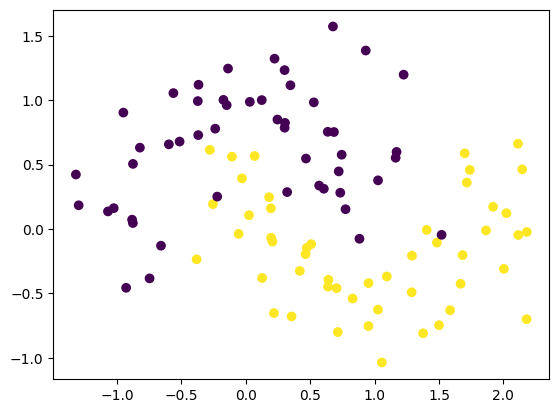

In [12]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [13]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [14]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [15]:
model = Sequential()

model.add(Dense(10,activation='sigmoid',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.summary()

c:\Users\shree\OneDrive\Desktop\Deep-learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Set parameters to 0
model.get_weights()

[array([[ 0.186575  ,  0.4420212 ,  0.57537156, -0.4621439 , -0.02762204,
         -0.481973  ,  0.46325165, -0.14608824, -0.30406034, -0.599797  ],
        [ 0.22149402, -0.3342454 ,  0.6786298 ,  0.31401962, -0.44666132,
         -0.5504198 ,  0.6257767 , -0.37769678,  0.5315073 , -0.36536023]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.32776836],
        [-0.21290606],
        [-0.41217393],
        [-0.72121173],
        [ 0.2080974 ],
        [-0.593417  ],
        [-0.3229778 ],
        [-0.07434559],
        [-0.23548585],
        [-0.01630133]], dtype=float32),
 array([0.], dtype=float32)]

In [17]:
initial_weights = model.get_weights()

In [18]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [19]:
model.set_weights(initial_weights)

In [20]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [21]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [22]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.4500 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss

In [23]:
model.get_weights()

[array([[-0.43732214, -0.43732214, -0.43732214, -0.43732214, -0.43732214,
         -0.43732214, -0.43732214, -0.43732214, -0.43732214, -0.43732214],
        [ 0.4582746 ,  0.4582746 ,  0.4582746 ,  0.4582746 ,  0.4582746 ,
          0.4582746 ,  0.4582746 ,  0.4582746 ,  0.4582746 ,  0.4582746 ]],
       dtype=float32),
 array([-0.08024377, -0.08024377, -0.08024377, -0.08024377, -0.08024377,
        -0.08024377, -0.08024377, -0.08024377, -0.08024377, -0.08024377],
       dtype=float32),
 array([[-0.05430293],
        [-0.05430293],
        [-0.05430293],
        [-0.05430293],
        [-0.05430293],
        [-0.05430293],
        [-0.05430293],
        [-0.05430293],
        [-0.05430293],
        [-0.05430293]], dtype=float32),
 array([0.04458102], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


<Axes: >

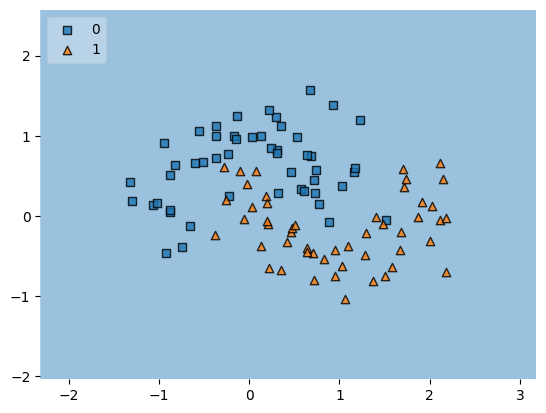

In [24]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)